In [43]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mubashirsidiki/student-academic-performance-500-students")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-academic-performance-500-students' dataset.
Path to dataset files: /kaggle/input/student-academic-performance-500-students


In [44]:
! pip install tensorflow
! pip install shap

In [45]:
import numpy as np
import pandas as pd
import shap
import tensorflow as tf
from  tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [46]:
df = pd.read_csv("/kaggle/input/student-academic-performance-500-students/student_performance.csv")
df

,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes
...,...,...,...,...,...,...,...,...,...,...,...
495,STU0496,Female,19,6,78.3,Master,No,No,51,27,No
496,STU0497,Female,16,27,61.1,PhD,No,No,47,74,Yes
497,STU0498,Female,18,16,72.3,Master,No,Yes,52,61,Yes
498,STU0499,Male,17,29,91.3,NaN,Yes,No,39,86,Yes


In [47]:
y=df['passed']
X=df.drop(['passed','student_id','parent_education','internet_access','gender','extracurricular'],axis=1)

X

,age,study_hours_per_week,attendance_rate,previous_score,final_score
0,15,25,63.8,41,67
1,15,2,54.7,83,28
2,19,10,90.5,73,49
3,16,26,66.8,75,70
4,15,25,73.0,67,77
...,...,...,...,...,...
495,19,6,78.3,51,27
496,16,27,61.1,47,74
497,18,16,72.3,52,61
498,17,29,91.3,39,86


In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [49]:
model=Sequential()
model.add(Dense(16,activation='relu',input_shape=(X_train.shape[1],)))
model.add(Dropout(0.2))
model.add(Dense(8,activation='relu'))
model.add(Dense(1,activation='sigmoid'))


model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])


y_train = y_train.map({'Yes': 1, 'No': 0})

model.fit(X_train,y_train,epochs=100,batch_size=32,verbose=1)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4525 - loss: 9.0535
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4825 - loss: 7.7304
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5425 - loss: 5.5207
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5200 - loss: 4.6839 
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5600 - loss: 3.6145
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6075 - loss: 3.3112
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6075 - loss: 2.7173
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6200 - loss: 2.5784
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6275 - loss: 2.1805
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6225 - loss: 2.1089
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6550 - loss: 1.7199  
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0

In [50]:
explainer = shap.KernelExplainer(model.predict, X_train[:100])
shap_values = explainer.shap_values(X_test[:50])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/

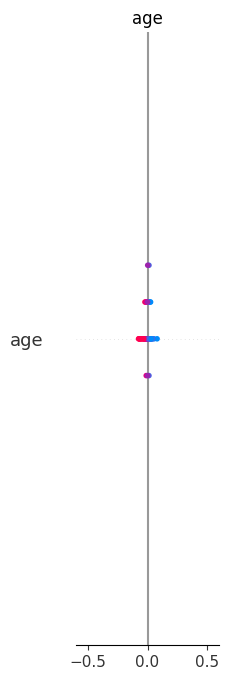

KeyError: 0

In [51]:
shap.summary_plot(shap_values, X_test[:50], feature_names=X.columns)
shap.force_plot(explainer.expected_value, shap_values[0], X_test[0], feature_names=X.columns)
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value, shap_values[0], feature_names=X.columns
)